# Proyek Klasifikasi Gambar: Kucing dan anjing 


- **Nama:** Muhammad Reza Pahlevi Harahap
- **Email:** mc156d5y0346@student.devacademy.id
- **ID Dicoding:** reza_harahap

## Data Preparation

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashfakyeafi/cat-dog-images-for-classification")

print("Path to dataset files:", path)

100%|██████████| 545M/545M [00:10<00:00, 53.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2


## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os


In [ ]:

# Tentukan path dataset
dataset_path = path

# Cek apakah folder dataset ada
if os.path.exists(dataset_path):
    print(f"Dataset ditemukan di: {dataset_path}")

    # Cek folder atau file yang ada di dalam dataset
    for root, dirs, files in os.walk(dataset_path):
        print(f"Root: {root}")
        print(f"Dirs: {dirs}")
        print(f"Files: {files}")
else:
    print(f"Dataset tidak ditemukan di path: {dataset_path}")


Dataset ditemukan di: /root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2
Root: /root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2
Dirs: ['cat_dog']
Files: ['cat_dog.csv']
Root: /root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2/cat_dog
Dirs: []
Files: ['dog.1231.jpg', 'dog.10165.jpg', 'dog.5076.jpg', 'dog.3639.jpg', 'cat.7671.jpg', 'cat.10420.jpg', 'dog.11179.jpg', 'cat.3278.jpg', 'cat.3046.jpg', 'dog.409.jpg', 'dog.472.jpg', 'cat.8349.jpg', 'cat.1188.jpg', 'dog.392.jpg', 'cat.3154.jpg', 'cat.3785.jpg', 'dog.8804.jpg', 'cat.376.jpg', 'cat.3978.jpg', 'cat.10654.jpg', 'dog.10142.jpg', 'dog.1771.jpg', 'cat.8714.jpg', 'dog.2357.jpg', 'cat.10680.jpg', 'dog.8620.jpg', 'cat.2970.jpg', 'dog.4655.jpg', 'dog.5974.jpg', 'dog.1472.jpg', 'dog.1575.jpg', 'cat.4154.jpg', 'dog.6638.jpg', 'dog.4093.jpg', 'dog.6643.jpg', 'dog.11994.jpg', 'cat.11847.jpg', 'cat.5071.jpg', 'dog.2086.jpg', 'dog.

### Data Loading

In [ ]:

csv_path = f"{dataset_path}/cat_dog.csv"
image_dir = f"{dataset_path}/cat_dog"

df = pd.read_csv(csv_path)

# Pastikan nama file cocok dengan nama file di folder
df['filename'] = df['image'].astype(str)
df['label'] = df['labels'].astype(str)

# Tampilkan beberapa baris
df.head()


,image,labels,filename,label
0,dog.11289.jpg,1,dog.11289.jpg,1
1,cat.10836.jpg,0,cat.10836.jpg,0
2,cat.7970.jpg,0,cat.7970.jpg,0
3,cat.2212.jpg,0,cat.2212.jpg,0
4,dog.2653.jpg,1,dog.2653.jpg,1


## Split Dataset

### Kemudian bagi data menjadi 70% untuk data train, 15% untuk data validasi, dan 15% untuk data test.

In [ ]:

# Pertama bagi jadi train dan temp (train 70%, sisanya 30%)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)

# Lalu bagi temp jadi val dan test masing-masing 15%
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

### cek resolusi dari data dan jumlah citra yang digunakan

In [ ]:


def get_images_resolution_info(directory):
    unique_sizes = set()
    total_images = 0

    image_files = os.listdir(directory)
    for img_file in image_files:
        img_path = os.path.join(directory, img_file)
        if os.path.isfile(img_path):
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
                    total_images += 1
            except Exception as e:
                print(f"Gagal membuka gambar {img_path}: {e}")

    return {
        "unique_sizes": list(unique_sizes),
        "total_images": total_images
    }


In [15]:
info = get_images_resolution_info(image_dir)

print("Resolusi unik:")
for size in info["unique_sizes"]:
    print(f"- {size}")

print(f"Total gambar: {info['total_images']}")


Resolusi unik:
- (247, 255)
- (500, 435)
- (445, 499)
- (150, 93)
- (241, 440)
- (375, 440)
- (460, 255)
- (262, 499)
- (396, 499)
- (418, 258)
- (382, 335)
- (327, 399)
- (500, 327)
- (444, 395)
- (475, 499)
- (347, 499)
- (306, 461)
- (479, 389)
- (231, 287)
- (96, 99)
- (349, 279)
- (426, 499)
- (500, 448)
- (99, 104)
- (200, 156)
- (357, 399)
- (398, 400)
- (351, 325)
- (446, 333)
- (418, 500)
- (284, 271)
- (430, 325)
- (449, 338)
- (173, 174)
- (319, 228)
- (379, 279)
- (439, 330)
- (199, 348)
- (400, 338)
- (59, 45)
- (251, 215)
- (335, 357)
- (333, 284)
- (252, 359)
- (291, 287)
- (356, 416)
- (309, 341)
- (395, 344)
- (199, 469)
- (400, 459)
- (196, 400)
- (330, 400)
- (449, 351)
- (435, 416)
- (261, 300)
- (443, 277)
- (300, 228)
- (249, 182)
- (340, 300)
- (298, 303)
- (499, 293)
- (399, 355)
- (251, 228)
- (228, 244)
- (441, 473)
- (205, 233)
- (499, 414)
- (399, 476)
- (311, 363)
- (416, 416)
- (490, 365)
- (316, 478)
- (429, 355)
- (1050, 702)
- (300, 241)
- (179, 180)
- 

### cek total data yang digunakan untuk training , validation dan testing

In [16]:
print("Train:")
print(train_df['label'].value_counts(), "\n")

print("Validation:")
print(val_df['label'].value_counts(), "\n")

print("Test:")
print(test_df['label'].value_counts())

Train:
label
1    8750
0    8750
Name: count, dtype: int64 

Validation:
label
1    1875
0    1875
Name: count, dtype: int64 

Test:
label
1    1875
0    1875
Name: count, dtype: int64


Semua gambar diskalakan ke 0-1, di-resize ke ukuran 150x150, dibagi dalam batch agar tidak perlu memuat semua gambar sekaligus, dan masing-masing data train, validasi, serta test dibuatkan generator-nya.


### Data Preprocessing

In [ ]:

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='filename',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='filename',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_gen = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='filename',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 17500 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.
Found 3750 validated image filenames belonging to 2 classes.


### Modeling

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Karena binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### latih model dengan data train dan validation untuk melakukan validasi model, menggunakan 15 epoch untuk percobaan

In [19]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


547/547 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.5731 - loss: 0.6744 - val_accuracy: 0.7099 - val_loss: 0.5672
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.7190 - loss: 0.5562 - val_accuracy: 0.7627 - val_loss: 0.4843
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.7712 - loss: 0.4760 - val_accuracy: 0.7981 - val_loss: 0.4371
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.8161 - loss: 0.4035 - val_accuracy: 0.8080 - val_loss: 0.4156
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.8448 - loss: 0.3552 - val_accuracy: 0.8200 - val_loss: 0.3948
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.8695 - loss: 0.3015 - val_accuracy: 0.8360 - val_loss: 0.3646
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.8960 - loss: 0.2470 - val_accuracy: 0.8381 - val_loss: 0.3882
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.9226 - loss: 0.1930 - val_accurac

## Evaluasi dan Visualisasi

In [20]:
# Evaluasi akhir di test set
test_loss, test_acc = model.evaluate(test_gen)


118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8562 - loss: 0.5978


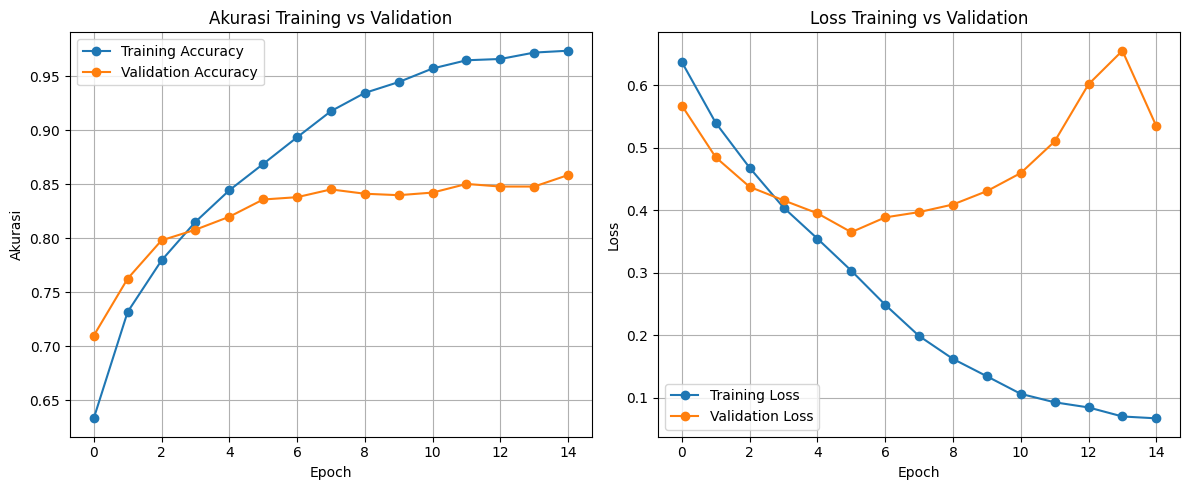

In [ ]:

# Plot akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Akurasi Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step


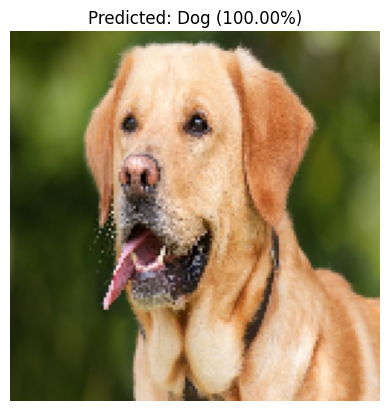

In [ ]:


image_path = '/content/drive/MyDrive/Tugas/cnn/anjing.jpg'

# Load dan preprocess gambar
img = image.load_img(image_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normalisasi
img_array = np.expand_dims(img_array, axis=0)  # Ubah ke shape (1, 150, 150, 3)

# Prediksi
prediction = model.predict(img_array)[0][0]

# Tampilkan gambar dan hasil prediksi
plt.imshow(img)
plt.axis('off')

label = "Dog" if prediction > 0.5 else "Cat"
confidence = prediction if prediction > 0.5 else 1 - prediction
plt.title(f"Predicted: {label} ({confidence * 100:.2f}%)")
plt.show()


## Konversi Model

In [ ]:
model.export("/content/drive/MyDrive/Tugas/cnn/cat_dog_savedmodel")


Saved artifact at '/content/drive/MyDrive/Tugas/cnn/cat_dog_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132390659689360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659691472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659692240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659689552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659692624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659693008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659694544: TensorSpec(shape=(), dtype=tf.re

In [25]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan file .tflite
with open("/content/drive/MyDrive/Tugas/cnn/cat_dog_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp0ony0ztg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132390659689360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659691472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659690896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659692240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659689552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659692624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659693008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390659694544: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [29]:
!tensorflowjs_converter --input_format=tf_saved_model --saved_model_tags=serve /content/drive/MyDrive/Tugas/cnn/cat_dog_savedmodel/ /content/drive/MyDrive/Tugas/cnn/model_tfjs


2025-04-27 05:56:23.740420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745733383.776215   11055 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745733383.787123   11055 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745733383.811976   11055 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745733383.812009   11055 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745733383.812017   11055 computation_placer.cc:177] computation placer alr